In [1]:
# Install required libraries (Colab already has most of these, this just makes sure)
!pip install -q nltk scikit-learn tensorflow keras pandas numpy matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, pickle, os

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("✅ All libraries loaded")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ All libraries loaded


In [4]:
# Mount Google Drive so your models/screenshots survive between Colab sessions
from google.colab import drive
drive.mount('/content/drive')

# Create your project folder structure inside Drive (matches the group repo layout)
BASE = '/content/drive/MyDrive/PhishGuard_Member2'
for folder in ['data', 'models', 'screenshots', 'notebooks']:
    os.makedirs(f'{BASE}/{folder}', exist_ok=True)

print("✅ Working folder ready at:", BASE)

Mounted at /content/drive
✅ Working folder ready at: /content/drive/MyDrive/PhishGuard_Member2


In [5]:
# --- Option A: Download via Kaggle API ---
# 1. Go to kaggle.com -> your profile -> Account -> Create New API Token (downloads kaggle.json)
# 2. Run this cell, then upload that kaggle.json when prompted

from google.colab import files
uploaded = files.upload()  # choose kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!pip install -q kaggle
!kaggle datasets download -d naserabdullahalam/phishing-email-dataset -p /content/data --unzip

Saving phishing_email.csv to phishing_email.csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset
License(s): CC-BY-SA-4.0
100% 77.1M/77.1M [00:00<00:00, 200MB/s]



In [6]:
# --- Option B: If you already have the CSV, upload it manually instead ---
# from google.colab import files
# uploaded = files.upload()   # select your CSV, then update the path below

import glob
csv_candidates = glob.glob('/content/data/*.csv') + glob.glob('/content/*.csv')
print("Found CSV files:", csv_candidates)

# Set this to the actual dataset file once you see the list above
DATA_PATH = csv_candidates[0] if csv_candidates else 'REPLACE_WITH_YOUR_CSV_PATH.csv'
print("Using:", DATA_PATH)

Found CSV files: ['/content/data/Ling.csv', '/content/data/Nazario.csv', '/content/data/Enron.csv', '/content/data/SpamAssasin.csv', '/content/data/CEAS_08.csv', '/content/data/Nigerian_Fraud.csv', '/content/data/phishing_email.csv', '/content/phishing_email.csv']
Using: /content/data/Ling.csv


In [7]:
# Load and inspect the dataset
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print()
print(df.columns.tolist())
print()
df.head()

Shape: (2859, 3)

['subject', 'body', 'label']



,subject,body,label
0,job posting - apple-iss research center,content - length : 3386 apple-iss research cen...,0
1,NaN,"lang classification grimes , joseph e . and ba...",0
2,query : letter frequencies for text identifica...,i am posting this inquiry for sergei atamas ( ...,0
3,risk,a colleague and i are researching the differin...,0
4,request book information,earlier this morning i was on the phone with a...,0


In [13]:
import pandas as pd

# NOTE: column names vary by source file inside this Kaggle dataset.
# Check your columns above and rename them to a consistent 'text' and 'label' here.
# Common raw names: 'text_combined', 'body', 'Email Text' / label: 'label', 'class'

# Rename the text column to 'text' for consistency
if 'body' in df.columns:
    df = df.rename(columns={'body': 'text'})
elif 'text_combined' in df.columns:
    df = df.rename(columns={'text_combined': 'text'})

df = df.dropna(subset=['text', 'label']).reset_index(drop=True)

print("Class counts:")
print(df['label'].value_counts())
print()
print("Sample phishing email:")
print(df[df['label'] == 1]['text'].iloc[0][:500])
print()
print("Sample legitimate email:")
print(df[df['label'] == 0]['text'].iloc[0][:500])

Class counts:
label
0    2401
1     458
Name: count, dtype: int64

Sample phishing email:
this is a multi-part message in mime format . - - - - - - = _ nextpart _ 000 _ 0139 _ 01bd8356 . 354ff2e0 content - type : multipart / alternative ; boundary = " - - - - = _ nextpart _ 001 _ 013a _ 01bd8356 . 354ff2e0 " - - - - - - = _ nextpart _ 001 _ 013a _ 01bd8356 . 354ff2e0 content - type : text / plain ; charset = " iso - 8859 - 1 " content - transfer - encoding : 7bit * * * scotland-net ~ make and save $ $ $ $ $ on the world wide web now ! * free web access ! ! ! free web access ! ! ! fre

Sample legitimate email:
content - length : 3386 apple-iss research center a us $ 10 million joint venture between apple computer inc . and the institute of systems science of the national university of singapore , located in singapore , is looking for : a senior speech scientist - - - - - - - - - - - - - - - - - - - - - - - - - the successful candidate will have research expertise in computational lingui

In [28]:
SAMPLE_SIZE = 12000

if len(df) > SAMPLE_SIZE:
    df, _ = train_test_split(
        df, train_size=SAMPLE_SIZE,
        stratify=df['label'], random_state=42
    )
    df = df.reset_index(drop=True)

print("Working dataset shape:", df.shape)
print(df['label'].value_counts())

Working dataset shape: (2858, 4)
label
0    2400
1     458
Name: count, dtype: int64


In [29]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                                  # lowercase
    text = re.sub(r'http\S+|www\S+', ' ', text)                # remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)                       # remove emails
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\d+', ' ', text)                           # remove numbers
    text = re.sub(r'\s+', ' ', text).strip()                   # remove extra whitespace

    tokens = word_tokenize(text)                               # tokenize
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]         # lemmatize

    return ' '.join(tokens)

# Quick test on one email
print(clean_text(df['text'].iloc[0][:500]))

content length appleiss research center million joint venture apple computer inc institute system science national university singapore located singapore looking senior speech scientist successful candidate research expertise computational linguistics including natural language processing english chinese statistical language modeling


In [30]:
# Apply to the FULL dataset (this can take a few minutes on 80k+ rows — that's normal)
df['cleaned_text'] = df['text'].apply(clean_text)

# Drop any rows that became empty after cleaning
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

print("Final shape after preprocessing:", df.shape)
df[['text', 'cleaned_text', 'label']].head()

Final shape after preprocessing: (2858, 4)


,text,cleaned_text,label
0,content - length : 3386 apple-iss research cen...,content length appleiss research center millio...,0
1,"lang classification grimes , joseph e . and ba...",lang classification grime joseph barbara grime...,0
2,i am posting this inquiry for sergei atamas ( ...,posting inquiry sergei atamas satamas umabnet ...,0
3,a colleague and i are researching the differin...,colleague researching differing degree risk pe...,0
4,earlier this morning i was on the phone with a...,earlier morning phone friend mine living south...,0


In [31]:
# Save a checkpoint of your cleaned dataset so you don't have to redo this every session
df.to_csv(f'{BASE}/data/cleaned_dataset_member2.csv', index=False)
print("✅ Saved cleaned dataset to Drive")

✅ Saved cleaned dataset to Drive


/tmp/ipykernel_596/1356125654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'])


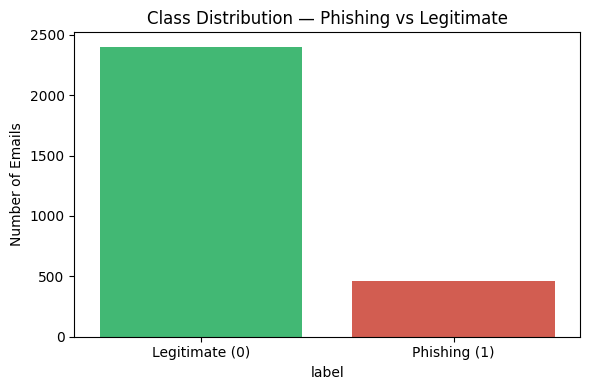

In [32]:
# --- Chart 1: Class distribution ---
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'])
plt.xticks([0,1], ['Legitimate (0)', 'Phishing (1)'])
plt.title('Class Distribution — Phishing vs Legitimate')
plt.ylabel('Number of Emails')
plt.tight_layout()
plt.savefig(f'{BASE}/screenshots/m2_class_dist.png', dpi=150)
plt.show()

/tmp/ipykernel_596/1200421957.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='Reds_r')


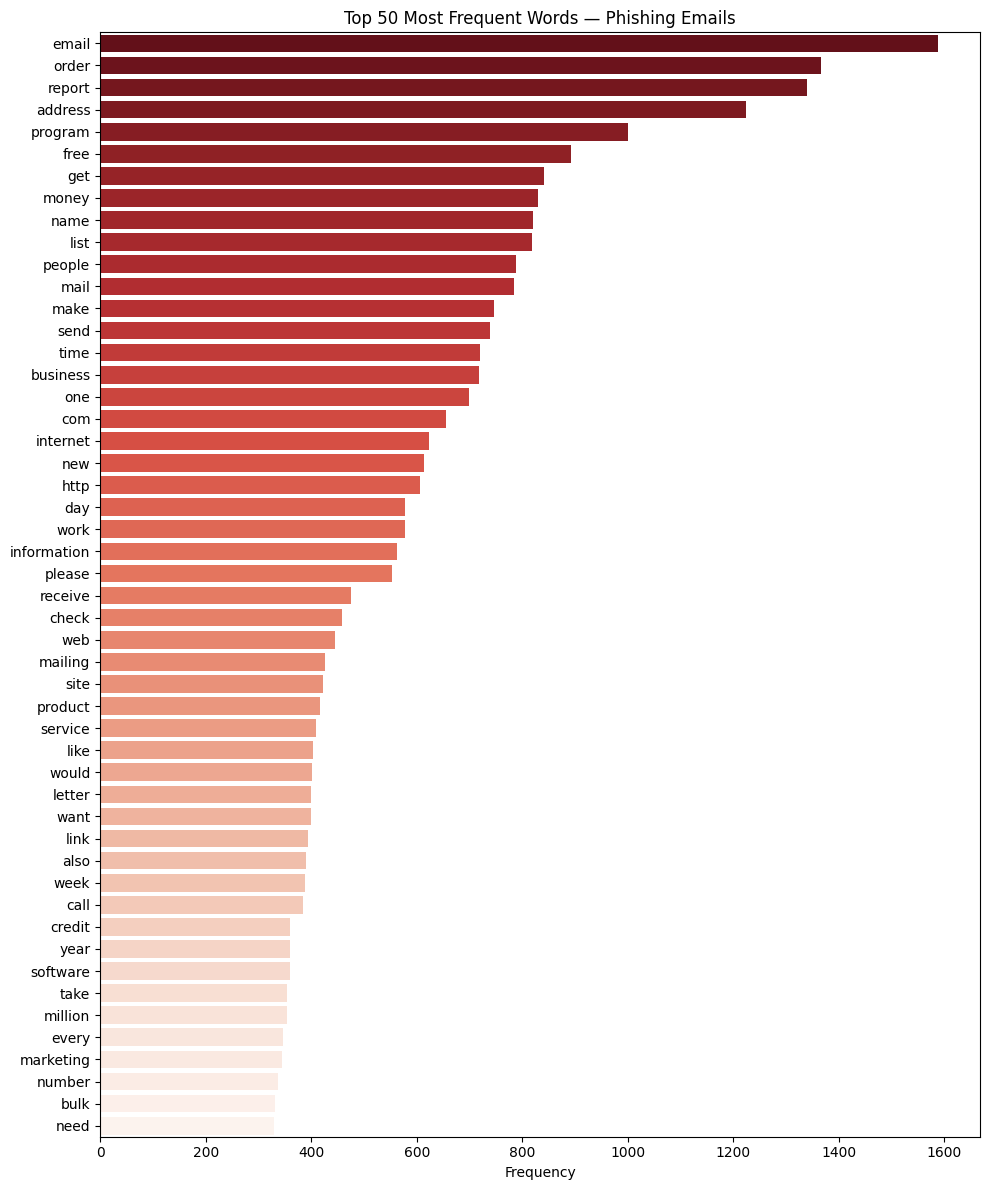

In [33]:
# --- Chart 2: Top 50 most frequent words in PHISHING emails ---
from collections import Counter

phishing_words = ' '.join(df[df['label'] == 1]['cleaned_text']).split()
top_50 = Counter(phishing_words).most_common(50)
words, counts = zip(*top_50)

plt.figure(figsize=(10,12))
sns.barplot(x=list(counts), y=list(words), palette='Reds_r')
plt.title('Top 50 Most Frequent Words — Phishing Emails')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig(f'{BASE}/screenshots/m2_top_words.png', dpi=150)
plt.show()

In [34]:
X = df['cleaned_text']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

# Save the vectorizer now (matches deliverable list: models/tfidf_member2.pkl)
with open(f'{BASE}/models/tfidf_member2.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✅ TF-IDF vectorizer saved")


Train shape: (2286, 10000)
Test shape: (572, 10000)
✅ TF-IDF vectorizer saved


In [35]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("=== Logistic Regression — Baseline Results ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:   ", recall_score(y_test, y_pred_lr))
print("F1-score: ", f1_score(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression — Baseline Results ===
Accuracy:  0.9755244755244755
Precision: 1.0
Recall:    0.8478260869565217
F1-score:  0.9176470588235294

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       480
           1       1.00      0.85      0.92        92

    accuracy                           0.98       572
   macro avg       0.99      0.92      0.95       572
weighted avg       0.98      0.98      0.97       572



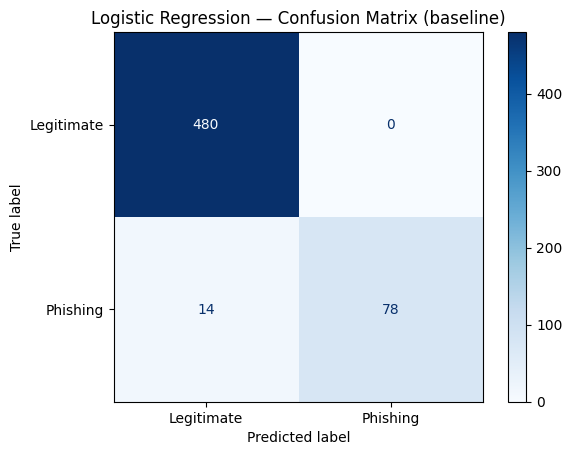

In [37]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate','Phishing'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix (baseline)')
plt.savefig(f'{BASE}/screenshots/m2_lr_cm.png', dpi=150)
plt.show()


In [39]:
# Save the baseline model
with open(f'{BASE}/models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("✅ Logistic Regression baseline model saved")

✅ Logistic Regression baseline model saved


In [40]:
# Tune regularization parameter C
best_f1 = 0
best_C = None

for C in [0.1, 1.0, 10.0]:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    f1 = f1_score(y_test, preds)
    print(f"C={C:<5} -> F1: {f1:.4f}")
    if f1 > best_f1:
        best_f1, best_C = f1, C

print(f"\n✅ Best C = {best_C} (F1 = {best_f1:.4f})")

C=0.1   -> F1: 0.1961
C=1.0   -> F1: 0.9176
C=10.0  -> F1: 0.9778

✅ Best C = 10.0 (F1 = 0.9778)


In [42]:
# Retrain final model with best C
lr_final = LogisticRegression(C=best_C, max_iter=1000, random_state=42)

# 10-fold cross-validation on the training set
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_final, X_train_tfidf, y_train, cv=cv, scoring='f1')
print("10-fold CV F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean(), "±", cv_scores.std())

lr_final.fit(X_train_tfidf, y_train)
y_pred_final = lr_final.predict(X_test_tfidf)
y_proba_final = lr_final.predict_proba(X_test_tfidf)[:, 1]

10-fold CV F1 scores: [0.94285714 0.94285714 0.92753623 1.         0.95774648 0.97222222
 0.97142857 0.92753623 0.95652174 0.95652174]
Mean CV F1: 0.9555227500267305 ± 0.02098656671575962


In [43]:
# Final metrics — RECORD THESE, you'll need them for Shakkya and the viva
lr_accuracy  = accuracy_score(y_test, y_pred_final)
lr_precision = precision_score(y_test, y_pred_final)
lr_recall    = recall_score(y_test, y_pred_final)
lr_f1        = f1_score(y_test, y_pred_final)
lr_roc_auc   = roc_auc_score(y_test, y_proba_final)

print("=== Logistic Regression — FINAL Results ===")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")

=== Logistic Regression — FINAL Results ===
Accuracy : 0.9930
Precision: 1.0000
Recall   : 0.9565
F1-score : 0.9778
ROC-AUC  : 1.0000


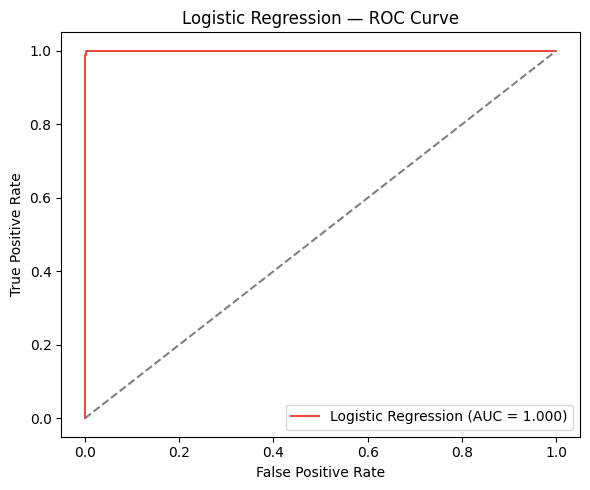

In [44]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {lr_roc_auc:.3f})', color='#e74c3c')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression — ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig(f'{BASE}/screenshots/m2_lr_roc.png', dpi=150)
plt.show()

In [45]:
# Save FINAL tuned model (overwrites baseline)
with open(f'{BASE}/models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_final, f)
print("✅ Final tuned Logistic Regression model saved")

✅ Final tuned Logistic Regression model saved
